<a href="https://colab.research.google.com/github/tomonari-masada/course2026-sml/blob/main/05_nearest_neighbors_2_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k近傍法 (2)
* 今回は、複数の特徴量を使って、k近傍法で予測をおこなう。

## 準備

### インポート

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

%config InlineBackend.figure_format = 'retina'

### データファイル

* `life_satisfaction_2010_2024.csv` を読み込む。

In [ ]:
df = pd.read_csv("life_satisfaction_2010_2024.csv")
df = df[df['Year'] == 2024]
df = df.set_index('Country')

* 日本をテストデータとして除外し、残りのデータ集合を使う。

In [ ]:
df_train = df.drop(['Japan'])
df_test  = df.loc[['Japan']]

In [ ]:
df_train

,Code,Year,Life Satisfaction,GDP per capita,Employment Rate (%)
Country,,,,,
Australia,AUS,2024,6.974,60303.980,77.06196
Austria,AUT,2024,6.810,63788.080,74.07500
Belgium,BEL,2024,6.910,63347.785,66.75000
Bulgaria,BGR,2024,5.554,34221.530,70.90000
Canada,CAN,2024,6.803,56706.824,74.67500
Switzerland,CHE,2024,6.935,82286.180,80.37500
Chile,CHL,2024,6.361,30182.787,64.13909
Colombia,COL,2024,6.004,18477.215,62.85250
Costa Rica,CRI,2024,7.274,26973.436,61.00788


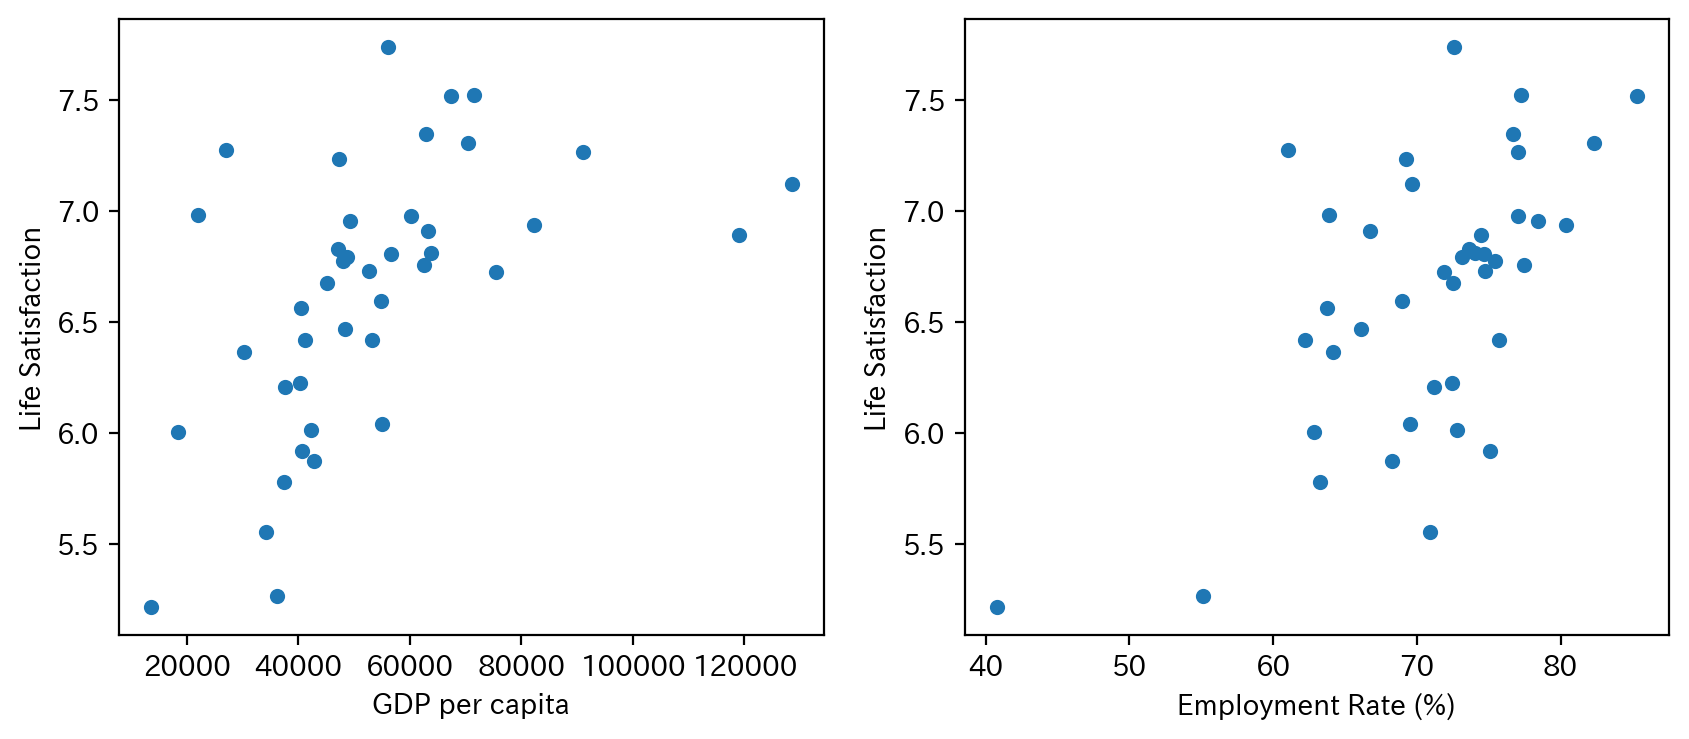

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_train.plot(kind='scatter', x='GDP per capita',      y='Life Satisfaction', ax=ax[0])
df_train.plot(kind='scatter', x='Employment Rate (%)', y='Life Satisfaction', ax=ax[1]);

In [ ]:
X = df_train[['GDP per capita', 'Employment Rate (%)']]
y = df_train['Life Satisfaction']

In [ ]:
X

,GDP per capita,Employment Rate (%)
Country,,
Australia,60303.980,77.06196
Austria,63788.080,74.07500
Belgium,63347.785,66.75000
Bulgaria,34221.530,70.90000
Canada,56706.824,74.67500
Switzerland,82286.180,80.37500
Chile,30182.787,64.13909
Colombia,18477.215,62.85250
Costa Rica,26973.436,61.00788


In [ ]:
y

Country
Australia         6.974
Austria           6.810
Belgium           6.910
Bulgaria          5.554
Canada            6.803
Switzerland       6.935
Chile             6.361
Colombia          6.004
Costa Rica        7.274
Czechia           6.775
Germany           6.753
Denmark           7.521
Spain             6.466
Estonia           6.417
Finland           7.736
France            6.593
United Kingdom    6.728
Greece            5.776
Croatia           5.870
Hungary           5.915
Ireland           6.889
Iceland           7.515
Israel            7.234
Italy             6.415
South Korea       6.038
Lithuania         6.829
Luxembourg        7.122
Latvia            6.207
Mexico            6.979
Netherlands       7.306
Norway            7.262
New Zealand       6.952
Poland            6.673
Portugal          6.013
Romania           6.563
Slovakia          6.221
Slovenia          6.792
Sweden            7.345
Turkey            5.262
United States     6.724
South Africa      5.213
Name: Li

## 今回の設定: 複数の特徴量を同時に使う
* 前回は、一人当たりのGDPと、雇用率を、別々に使った。
* 今回は、これら二つの特徴量を、同時に使いたい。
  * つまり、(一人当たりのGDP, 雇用率) という2次元ベクトルを使って、生活満足度を予測したい。

### 演習問題1
* 韓国とイタリアの距離を、一人当たりのGDPと雇用率を同時に使って計算したい。
* しかし、下に示す距離の計算方法には、問題がある。どのような問題があるか。

In [ ]:
print(np.linalg.norm(X.loc['South Korea'] - X.loc['Italy']))

1805.948931250741


#### 解答1
* `GDP per capita` の値は数万ドル規模、`Employment Rate (%)` は 0〜100 の範囲と、**スケール（単位）が大きく異なる**。
* そのため、ユークリッド距離を単純に計算すると、GDPの差が圧倒的に支配してしまい、
  雇用率の情報がほとんど反映されない。
* 以下の例でも分かる通り、距離の大部分がGDPの差（約1800）によるものであり、
  雇用率の差（約7）はほぼ無視されてしまっている。

```
South Korea: GDP=55070, Employment=69.54
Italy:       GDP=53265, Employment=62.20
差:          GDP≈1805,  Employment≈7.3  → 距離≈1805.95
```

* **解決策**: 各特徴量を**標準化**（平均0・標準偏差1に変換）してからユークリッド距離を計算する。

### 演習問題2
* 上で見つけた問題を解決した上で、あらためて、韓国とイタリアの距離を求めてみよう。

In [ ]:
# 標準化: 各特徴量を平均0・標準偏差1に変換する
X_mean = X.mean()
X_std  = X.std()
X_scaled = (X - X_mean) / X_std

print('標準化後の基本統計:')
print(X_scaled.describe().round(4))


標準化後の基本統計:
       GDP per capita  Employment Rate (%)
count         41.0000              41.0000
mean          -0.0000              -0.0000
std            1.0000               1.0000
min           -1.7222              -3.8216
25%           -0.5554              -0.5148
50%           -0.2021               0.2197
75%            0.4193               0.5886
max            3.2597               1.8477


In [ ]:
# 韓国とイタリアの距離（標準化後）
dist_scaled = np.linalg.norm(X_scaled.loc['South Korea'] - X_scaled.loc['Italy'])
print(f'標準化前の距離: {np.linalg.norm(X.loc["South Korea"] - X.loc["Italy"]):.2f}')
print(f'標準化後の距離: {dist_scaled:.4f}')
print('→ 両特徴量がほぼ同等に扱われるようになった')

標準化前の距離: 1805.95
標準化後の距離: 0.9373
→ 両特徴量がほぼ同等に扱われるようになった


## 訓練データ/検証データ/テストデータ

### テストデータ (test set)
* 最終的にそれについて予測を行なうことで、手法の評価をおこないたいデータを、テストデータと呼ぶ。
* 今回は、日本のデータがテストデータになる。

### 検証データ (validation set)
* 最適な近傍の個数 k を、どうやって求めたらいいだろうか。
* テストデータでの評価は最終評価なので、最後に一度行うだけ（カンニング禁止）。
* そこで、テストデータ以外のデータを使って予測・評価することで k を決める。
* このように **ハイパーパラメータを決めるために使うデータ** を、検証データと呼ぶ。

### 訓練データ (training set)
* 予測を実行するための手掛かりとするデータ集合を、訓練データと呼ぶ。
* k近傍法では、その中から近傍をk個見つけてくるデータ集合が訓練データになる。

## 最適なkの決定
* ここでは、韓国を検証データとして使う。
* 韓国の生活満足度を予測し、最も良い予測値を与える k がいくらか調べる。

### 演習問題3
* 韓国の生活満足度を予測し、最も良い予測値を与えるkを調べよう。

In [ ]:
# ---- k近傍法の手動実装 (sklearnを使わない) ----

def knn_predict(X_train_sc, y_train, x_query_sc, k):
    """標準化済みの訓練データと1件のクエリから予測値を返す。"""
    dists = np.array([
        np.linalg.norm(x_query_sc - X_train_sc.loc[c].values)
        for c in X_train_sc.index
    ])
    nn_indices = np.argsort(dists)[:k]
    return y_train.iloc[nn_indices].mean()


韓国を検証データとした場合の最適k: 20
そのときの予測誤差 (MAE): 0.5254


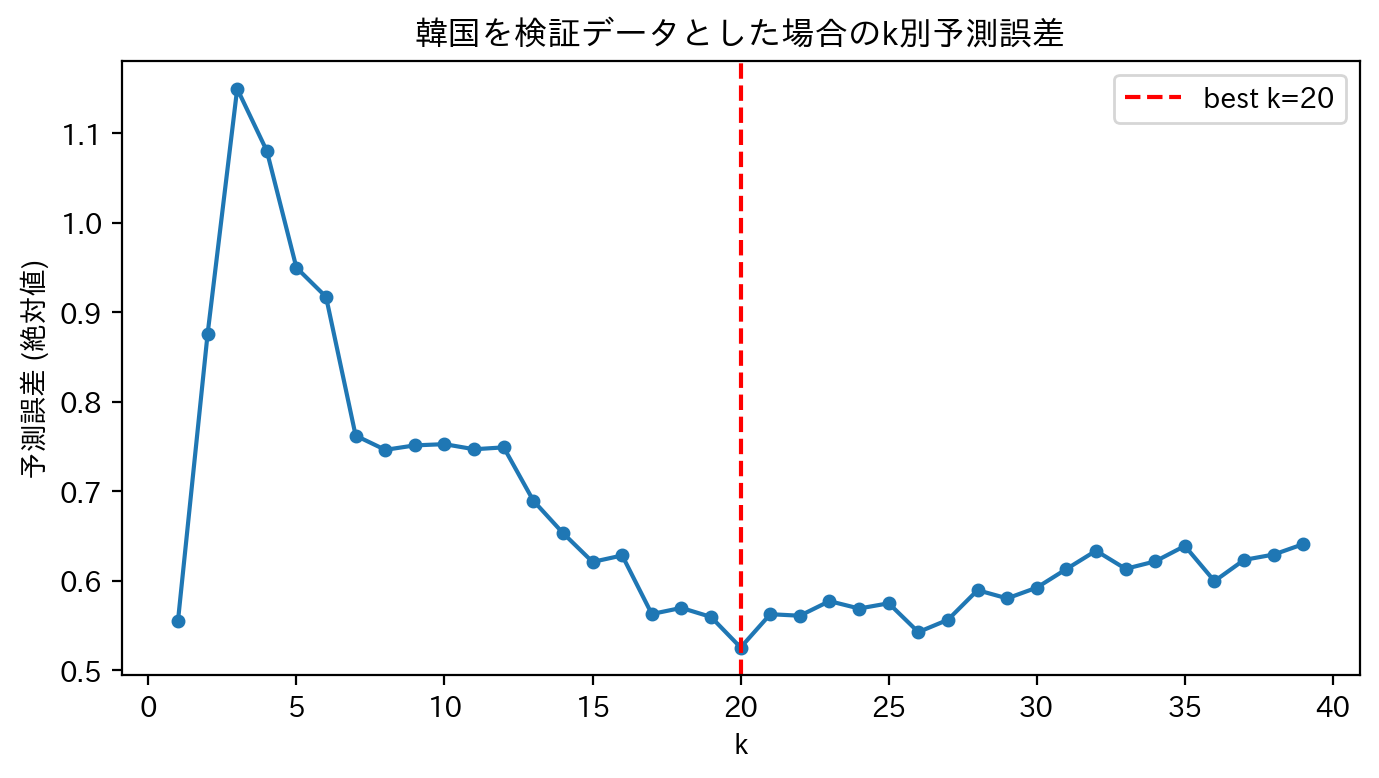

In [ ]:
# 韓国を検証データとして除外した訓練セットで標準化
val_country = 'South Korea'

X_tr_sk  = X.drop(val_country)
y_tr_sk  = y.drop(val_country)
X_val_sk = X.loc[[val_country]]

# 訓練データのみで mean/std を計算（データリーク防止）
mean_sk = X_tr_sk.mean()
std_sk  = X_tr_sk.std()
X_tr_sk_sc  = (X_tr_sk  - mean_sk) / std_sk
X_val_sk_sc = (X_val_sk - mean_sk) / std_sk

# k=1〜len(訓練データ)-1 で予測誤差を計算
k_values = range(1, len(X_tr_sk_sc))
errors_sk = []
for k in k_values:
    pred  = knn_predict(X_tr_sk_sc, y_tr_sk, X_val_sk_sc.values[0], k)
    error = abs(pred - y.loc[val_country])
    errors_sk.append(error)

best_k_sk = list(k_values)[np.argmin(errors_sk)]
print(f'韓国を検証データとした場合の最適k: {best_k_sk}')
print(f'そのときの予測誤差 (MAE): {min(errors_sk):.4f}')

# 可視化
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), errors_sk, marker='o', markersize=4)
plt.axvline(best_k_sk, color='red', linestyle='--', label=f'best k={best_k_sk}')
plt.xlabel('k')
plt.ylabel('予測誤差 (絶対値)')
plt.title('韓国を検証データとした場合のk別予測誤差')
plt.legend()
plt.tight_layout()
plt.show()

## 交差検証 (cross-validation)
* 検証データの取り方を何通りも変えつつ予測手法の評価を繰り返すことで手法の性能を検証することを、交差検証と呼ぶ。

## leave-one-out交差検証 (1)
* 上では、韓国を検証データとして使った。
* 他の国を検証データとしても構わないはずである。
* そこで、他の国の一つ一つを検証データとした場合の、それぞれ最適なkの値を求めてみる。
  * 検証データが1個の場合の交差検証を、**leave-one-out交差検証**と呼ぶ。

### 演習問題4
* 韓国について行ったことと同じことを、他の国についても実行し・・・
* 最適なkの値がどのくらい違ってくるか、調べてみよう。

In [ ]:
# 各国を1つずつ検証データとして、最適なkを求める
best_k_per_country = {}

for val_country in X.index:
    X_tr  = X.drop(val_country)
    y_tr  = y.drop(val_country)
    X_val = X.loc[[val_country]]

    # 訓練データのみで標準化
    mean_c = X_tr.mean()
    std_c  = X_tr.std()
    X_tr_sc  = (X_tr  - mean_c) / std_c
    X_val_sc = (X_val - mean_c) / std_c

    errs = []
    for k in range(1, len(X_tr_sc)):
        pred  = knn_predict(X_tr_sc, y_tr, X_val_sc.values[0], k)
        errs.append(abs(pred - y.loc[val_country]))

    best_k_per_country[val_country] = np.argmin(errs) + 1  # k は1始まり

result_series = pd.Series(best_k_per_country, name='best_k')
print(result_series.to_string())
print(f'\n最頻値: {result_series.mode().values}')
print(f'平均値: {result_series.mean():.1f}')
print(f'中央値: {result_series.median()}')

Australia          3
Austria            1
Belgium            6
Bulgaria           4
Canada            13
Switzerland       20
Chile             21
Colombia           8
Costa Rica         2
Czechia            2
Germany           28
Denmark            1
Spain              5
Estonia           11
Finland            1
France            29
United Kingdom    20
Greece            15
Croatia            9
Hungary            2
Ireland           26
Iceland            1
Israel            39
Italy              9
South Korea       20
Lithuania          1
Luxembourg        13
Latvia             7
Mexico            39
Netherlands        3
Norway             2
New Zealand       17
Poland            35
Portugal           1
Romania           33
Slovakia           6
Slovenia           6
Sweden             7
Turkey            17
United States     32
South Africa       1

最頻値: [1]
平均値: 12.6
中央値: 8.0


* 最適なkを、どのようにして決めればいいだろうか？
  * 例えば、各国について得られたkの平均をとることが考えられるが、これは良い方法と言えるだろうか？
  * → 各国での「最適k」はバラつきが大きく、単純な平均は不安定。より良い方法を演習5〜8で考える。

## leave-one-out交差検証 (2)
* 上では国ごとに最適kを求めたが、まとめ方が難しかった。
* より良い方法として、**各kについて全国の予測誤差を平均し、その平均誤差が最小のkを選ぶ**。

### 演習問題5
* 韓国を検証データとする。つまり、韓国について予測を行なう。
* kの値を変えたとき、それぞれ予測誤差がいくらになるか、求めてみよう。

In [ ]:
# 韓国の場合の k 別予測誤差を表示
val_country = 'South Korea'
X_tr  = X.drop(val_country)
y_tr  = y.drop(val_country)
X_val = X.loc[[val_country]]

mean_c = X_tr.mean()
std_c  = X_tr.std()
X_tr_sc  = (X_tr  - mean_c) / std_c
X_val_sc = (X_val - mean_c) / std_c

k_list = list(range(1, len(X_tr_sc)))
err_list = []
for k in k_list:
    pred  = knn_predict(X_tr_sc, y_tr, X_val_sc.values[0], k)
    err_list.append(abs(pred - y.loc[val_country]))

err_sk = pd.Series(err_list, index=k_list, name='South Korea')
print(err_sk.to_frame().T.to_string())

                1       2         3        4       5         6         7        8         9       10        11     12        13        14     15       16        17        18        19      20        21        22        23        24      25        26       27        28        29      30        31        32        33        34        35        36       37        38        39
South Korea  0.555  0.8755  1.149667  1.08025  0.9498  0.917167  0.762143  0.74625  0.751222  0.7526  0.746909  0.749  0.689462  0.653286  0.621  0.62825  0.562824  0.569667  0.559526  0.5254  0.562619  0.560909  0.577217  0.568958  0.5748  0.542615  0.55637  0.589464  0.580276  0.5923  0.613065  0.633531  0.613303  0.621647  0.638857  0.599556  0.62327  0.629263  0.640923


### 演習問題6
* 縦が国名、横がkの値の表を、データフレームとして作った上で・・・
* 日本を除く国の一つ一つを検証データとして評価していくことで・・・
* 各々のkの値で予測誤差がいくらになるかで、表を埋めてみよう。

In [ ]:
# LOO-CV の誤差テーブルを作成
k_list     = list(range(1, len(X)))  # k=1〜(国数-1)
error_table = {}                     # {country: [error_k1, error_k2, ...]}

for val_country in X.index:
    X_tr  = X.drop(val_country)
    y_tr  = y.drop(val_country)
    X_val = X.loc[[val_country]]

    mean_c = X_tr.mean()
    std_c  = X_tr.std()
    X_tr_sc  = (X_tr  - mean_c) / std_c
    X_val_sc = (X_val - mean_c) / std_c

    errs = []
    for k in k_list:
        pred  = knn_predict(X_tr_sc, y_tr, X_val_sc.values[0], k)
        errs.append(abs(pred - y.loc[val_country]))

    error_table[val_country] = errs

# DataFrameに変換: 行=国、列=k
error_df = pd.DataFrame(error_table, index=k_list).T
error_df.columns.name = 'k'
print('誤差テーブル（行=国、列=k）の先頭5列')
error_df.iloc[:, :].round(4)

誤差テーブル（行=国、列=k）の先頭5列


k,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
Australia,0.221,0.0750,0.0070,0.0463,0.0862,0.0193,0.0134,0.0131,0.0730,0.0475,...,0.2684,0.2974,0.3070,0.2978,0.2807,0.2753,0.2941,0.3314,0.3191,0.3551
Austria,0.007,0.2640,0.4847,0.4045,0.3122,0.2465,0.3129,0.2630,0.2318,0.1314,...,0.0991,0.1283,0.1380,0.1290,0.1120,0.1067,0.1256,0.1631,0.1509,0.1870
Belgium,0.317,0.5945,0.5443,0.5320,0.3608,0.1630,0.1663,0.2755,0.2560,0.2422,...,0.2779,0.2671,0.3089,0.2991,0.2793,0.2967,0.2723,0.2657,0.2534,0.2895
Bulgaria,0.653,0.6600,0.5930,0.5238,0.6428,0.5958,0.7507,0.8163,0.8214,0.8631,...,1.0637,1.0920,1.0500,1.0707,1.0961,1.1040,1.1204,1.1260,1.0884,1.1004
Canada,0.075,0.4290,0.2883,0.2590,0.3156,0.2583,0.2199,0.1956,0.1683,0.1385,...,0.0918,0.1211,0.1308,0.1218,0.1048,0.1241,0.1624,0.1559,0.1437,0.1798
Switzerland,0.327,0.3490,0.4280,0.4660,0.3364,0.3487,0.3044,0.2400,0.1994,0.1663,...,0.1948,0.2049,0.2100,0.2379,0.2475,0.2394,0.2238,0.2424,0.2791,0.3151
Chile,0.585,0.0165,0.3153,0.2870,0.1582,0.0500,0.0579,0.0503,0.0618,0.0317,...,0.1835,0.1892,0.2186,0.2399,0.2003,0.2107,0.2293,0.2537,0.2607,0.2732
Colombia,0.975,1.1225,0.8673,0.5935,0.5866,0.4138,0.2487,0.2009,0.2011,0.2272,...,0.5521,0.5573,0.5165,0.5459,0.5675,0.5937,0.6028,0.6201,0.6268,0.6391
Costa Rica,0.913,0.6040,0.8260,0.9940,0.9374,1.1165,1.0724,1.0458,1.0856,1.1490,...,0.7598,0.7524,0.7920,0.7615,0.7388,0.7277,0.7084,0.6834,0.6757,0.6626
Czechia,0.047,0.0035,0.0080,0.0835,0.2388,0.2160,0.1811,0.1364,0.2059,0.2407,...,0.1126,0.1203,0.1105,0.0929,0.1123,0.0953,0.1336,0.1271,0.1150,0.1512


### 演習問題7
* 上で作った表で、それぞれのkの値について、予測誤差の平均値を求めてみよう。

k別の平均予測誤差:
k
1     0.4845
2     0.4189
3     0.4348
4     0.4203
5     0.4226
6     0.3882
7     0.3871
8     0.3807
9     0.3773
10    0.3860
11    0.3689
12    0.3666
13    0.3752
14    0.3659
15    0.3745
16    0.3783
17    0.3815
18    0.3878
19    0.3900
20    0.3915
21    0.4007
22    0.4030
23    0.4039
24    0.4079
25    0.4086
26    0.4095
27    0.4148
28    0.4203
29    0.4277
30    0.4316
31    0.4341
32    0.4439
33    0.4511
34    0.4569
35    0.4602
36    0.4595
37    0.4666
38    0.4694
39    0.4745
40    0.4890


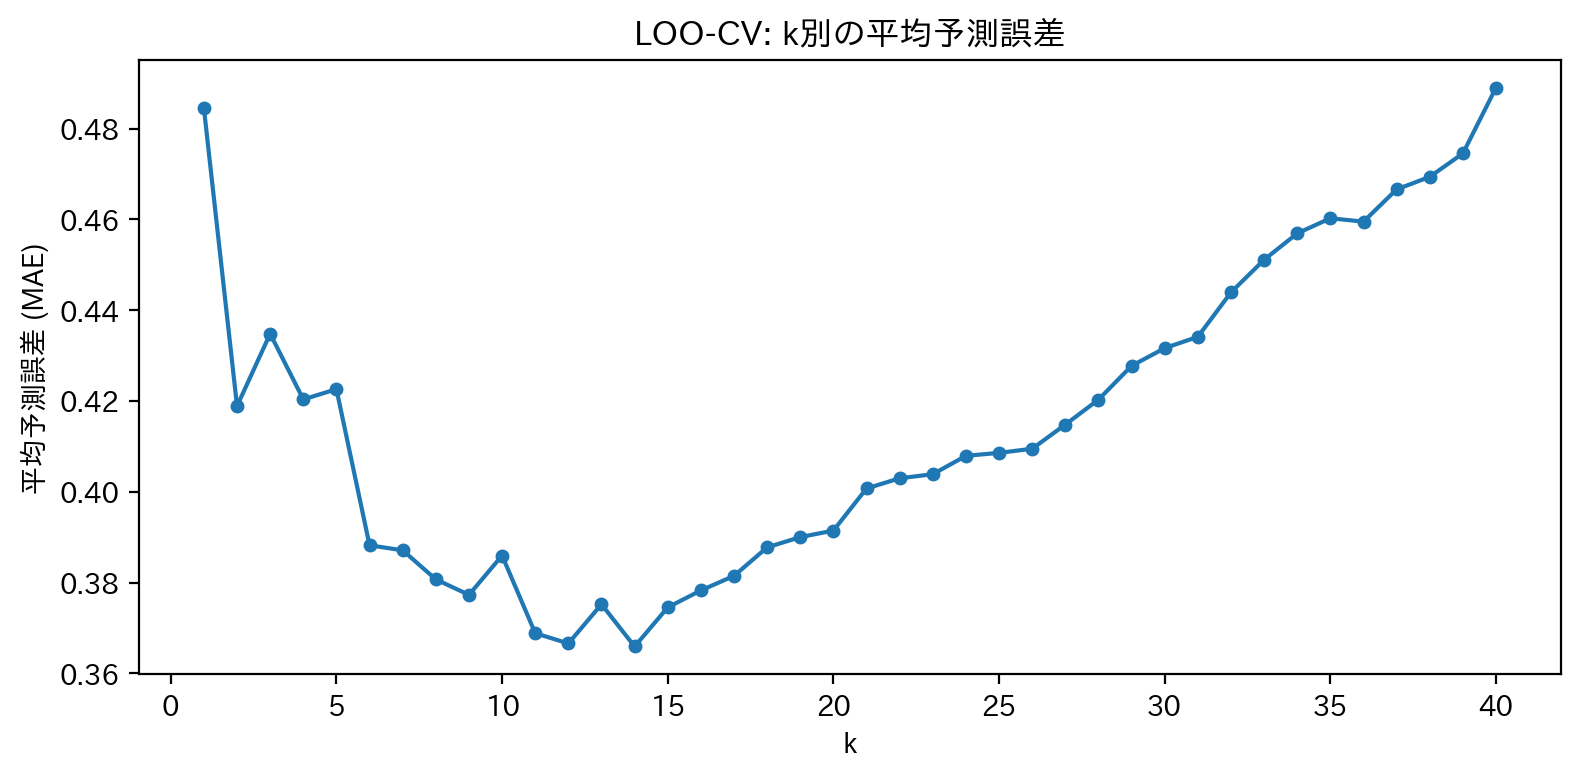

In [ ]:
# k別の平均予測誤差
mean_errors = error_df.mean(axis=0)  # 行方向（国）で平均
mean_errors.index = mean_errors.index.astype(int)

print('k別の平均予測誤差:')
print(mean_errors.round(4).to_string())

plt.figure(figsize=(8, 4))
mean_errors.plot(marker='o', markersize=4)
plt.xlabel('k')
plt.ylabel('平均予測誤差 (MAE)')
plt.title('LOO-CV: k別の平均予測誤差')
plt.tight_layout()
plt.show()

### 演習問題8
* 上で求めた予測誤差の平均値を、最も小さくするkの値は？

In [ ]:
best_k_loo = int(mean_errors.idxmin())
print(f'LOO-CVで選ばれた最適k: {best_k_loo}')
print(f'そのときの平均予測誤差 (MAE): {mean_errors[best_k_loo]:.4f}')

LOO-CVで選ばれた最適k: 14
そのときの平均予測誤差 (MAE): 0.3659


### 演習問題9
* こうして求めた最適なkを使って、最終的に、日本の生活満足度の予測をしてみよう。
  * ここで初めてテストデータを使う。

In [ ]:
# ここで初めてテストデータ（日本）を使う
# 訓練データ全体（日本を除いた全国）で標準化パラメータを推定
mean_final = X.mean()
std_final  = X.std()
X_train_sc_final = (X - mean_final) / std_final

# テストデータも同じパラメータで標準化
X_test = df_test[['GDP per capita', 'Employment Rate (%)']]
X_test_sc = (X_test - mean_final) / std_final

# 予測
pred_japan = knn_predict(
    X_train_sc_final, y, X_test_sc.values[0], best_k_loo
)
actual_japan = df_test['Life Satisfaction'].values[0]

print(f'使用したk: {best_k_loo}')
print(f'日本の予測生活満足度: {pred_japan:.3f}')
print(f'日本の実際の生活満足度: {actual_japan:.3f}')
print(f'予測誤差 (絶対値): {abs(pred_japan - actual_japan):.3f}')

# k近傍の国を表示
dists = np.array([
    np.linalg.norm(X_test_sc.values[0] - X_train_sc_final.loc[c].values)
    for c in X_train_sc_final.index
])
nn_idx = np.argsort(dists)[:best_k_loo]
print(f'\n日本の{best_k_loo}近傍の国:')
neighbors = pd.DataFrame({
    '距離': dists[nn_idx],
    'Life Satisfaction': y.iloc[nn_idx].values
}, index=y.index[nn_idx])
print(neighbors.round(4))

使用したk: 14
日本の予測生活満足度: 6.656
日本の実際の生活満足度: 6.147
予測誤差 (絶対値): 0.509

日本の14近傍の国:
                    距離  Life Satisfaction
Country                                  
New Zealand     0.1869              6.952
Czechia         0.5168              6.775
Estonia         0.5183              6.417
Hungary         0.5998              5.915
United Kingdom  0.6599              6.728
Australia       0.6859              6.974
Lithuania       0.7409              6.829
Germany         0.7568              6.753
Canada          0.7606              6.803
Slovenia        0.8074              6.792
Sweden          0.8118              7.345
Portugal        0.8612              6.013
Poland          0.8803              6.673
Slovakia        0.9267              6.221


# 課題
* 上のnotebookを最後まで実践することが、今回の課題です。